# Análise Exploratória de Dados — Steam (Dataset V2)
### TCC — Análise e Predição de Popularidade de Jogos na Plataforma Steam

**Discente:** Davi Augusto Farinela da Silva
**Orientador:** Prof. Dr. João Henrique Ferreira Flores

---

Essa é uma versão revisada da AED que eu tinha feito em cima do dataset V2. Resolvi refazer porque, revisando o notebook anterior, achei duas coisas que precisavam de correção antes de eu te mandar: um número que ficou desatualizado de um rascunho anterior (a categorização de popularidade dizia "mais de 52% sem avaliação", mas o valor real calculado no próprio notebook é outro — corrigi abaixo) e uma célula que só rodava porque tinha variável reaproveitada do kernel de uma execução anterior (rodei tudo de novo do zero pra garantir que não tem esse tipo de problema escondido).

Também aproveitei pra responder, com número na mão, a dúvida que ficou em aberto no notebook anterior: **de onde vinham aqueles NaN enormes em `reviews_total` que eu tinha na primeira coleta** (a que está descrita na Seção 3.1 do TCC agora). Isso está logo na próxima seção, porque acho que é o ponto mais importante pra decidirmos o que muda no texto do TCC.

## 1. De onde vinham os NaN em `reviews_total`?

Antes de eu escrever a AED de novo, queria confirmar uma coisa: aqueles ~87% de `reviews_total` faltante que relatei na Tabela 3.2 do TCC — isso é erro de alguma etapa da minha análise (EDA/curadoria), erro da coleta, ou é assim mesmo que o banco da Steam se comporta?

A resposta, depois de checar: **não é erro nem de EDA nem de coleta em si — é uma limitação estrutural do campo que eu estava usando.** Minha primeira coleta (`api-atomica.py`) lia o campo `recommendations.total` do endpoint `appdetails`. Só que a Steam **não retorna esse campo** para jogos abaixo de um limiar de avaliações que eles não documentam publicamente. Ou seja, quando o campo não vinha, eu não conseguia saber se era porque o jogo tinha 0 avaliações ou porque só estava abaixo desse limiar invisível — e isso é exatamente o viés de seleção que eu já tinha citado na Seção 3.1 do TCC.

Só que existe outro endpoint da Steam, o `/appreviews`, que retorna um resumo (`query_summary`) com o total de avaliações pra **qualquer** app, incluindo `0` de forma explícita quando o jogo realmente não tem nenhuma. Refiz a coleta usando esse endpoint (é o que gerou o `checkpoints_v2/`) e guardei o resultado no campo `exact_reviews`.

Pra confirmar que a melhora é real (e não só um efeito de ter coletado em outra data, com outro catálogo de jogos), comparei os dois campos **dentro do mesmo dataset V2** — ou seja, nos mesmos 171.769 apps, olhando o quanto cada campo falta:

In [1]:
import pickle
from pathlib import Path

CKPT_V2 = Path(r"checkpoints_v2/apps_dict-v2.p")

print("Carregando checkpoints_v2/apps_dict-v2.p (~2,3 GB, pode levar alguns minutos)...")
with open(CKPT_V2, "rb") as f:
    app_data_v2 = pickle.load(f)

total = len(app_data_v2)
sem_recommendations = sum(1 for v in app_data_v2.values() if not v.get("recommendations"))
sem_exact_reviews    = sum(1 for v in app_data_v2.values() if not v.get("exact_reviews"))

print(f"Total de apps no dataset V2: {total:,}\n")
print(f"Sem 'recommendations.total' (campo usado na 1ª coleta) : {sem_recommendations:,}  ({sem_recommendations/total*100:.1f}%)")
print(f"Sem 'exact_reviews'        (campo usado na 2ª coleta)  : {sem_exact_reviews:,}  ({sem_exact_reviews/total*100:.1f}%)")

Carregando checkpoints_v2/apps_dict-v2.p (~2,3 GB, pode levar alguns minutos)...


Total de apps no dataset V2: 171,769

Sem 'recommendations.total' (campo usado na 1ª coleta) : 150,443  (87.6%)
Sem 'exact_reviews'        (campo usado na 2ª coleta)  : 520  (0.3%)


Dá pra ver que, nos **mesmos apps**, o campo antigo (`recommendations`) falta em quase 9 a cada 10 jogos, enquanto o campo novo (`exact_reviews`) falta em menos de 1 em cada 200 — e o que resta ali são falhas reais de coleta (timeout, app removido da loja entre a listagem e a consulta, etc.), não um limiar da API. Como é o mesmo conjunto de apps nas duas colunas, dá pra descartar a hipótese de que a melhora é só porque coletei em outra data ou peguei um catálogo diferente — é o campo mesmo que resolve o problema.

**Conclusão pro TCC:** a Tabela 3.2 e o parágrafo da Seção 3.1 sobre o viés de seleção em `reviews_total` estão descrevendo um problema que já não existe mais no pipeline atual — só ainda não documentei essa correção no texto. Isso vai virar uma reescrita da Metodologia (mais detalhes na última seção deste notebook).

## 2. Carregamento e Configuração

Daqui pra frente é a AED "normal" em cima do `steam-jogos-v2.csv` (o CSV já curado, só jogos, gerado pelo `steam-analise-v2.py`).

In [2]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
sns.set_style("ticks")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

IMG_DIR = Path("imgs")
IMG_DIR.mkdir(exist_ok=True)

df = pd.read_csv("data/steam-jogos-v2.csv", low_memory=False)
print(f"Dimensões: {df.shape[0]:,} jogos x {df.shape[1]} colunas")

Dimensões: 118,596 jogos x 51 colunas


## Visão Geral do Dataset

In [3]:
print("Tipos de Dados")
print(df.dtypes.to_string())

Tipos de Dados
appid                               int64
name                                  str
type                                  str
is_free                              bool
price_brl                         float64
reviews_total                     float64
reviews_positive                  float64
reviews_negative                  float64
review_score                      float64
review_score_desc                     str
recommendations_total             float64
achievements_total                float64
required_age                        int64
metacritic_score                  float64
supported_languages_count           int64
dlc_count                           int64
has_demos                            bool
windows                              bool
mac                                  bool
linux                                bool
release_date                          str
genre_action                         bool
genre_adventure                      bool
genre_casual       

In [4]:
cols_amostra = ["appid", "name", "is_free", "price_brl",
                "reviews_total", "reviews_positive", "reviews_negative",
                "review_score_desc", "release_year"]
df[cols_amostra].head()

,appid,name,is_free,price_brl,reviews_total,reviews_positive,reviews_negative,review_score_desc,release_year
0,2621440,Infinity Castle Dungeon,False,13.79,32.0,27.0,5.0,Positive,2024.0
1,1048580,Terje Haakonsen's Powder VR,False,37.99,56.0,39.0,17.0,Mixed,2020.0
2,2097160,Monster Mystery,True,0.00,0.0,0.0,0.0,No user reviews,2022.0
3,10,Counter-Strike,False,20.69,168343.0,163264.0,5079.0,Overwhelmingly Positive,2000.0
4,3145740,VRider SBK™,False,59.62,18.0,9.0,9.0,Mixed,2025.0


In [5]:
cols_num = ["price_brl", "reviews_total", "reviews_positive", "reviews_negative",
            "achievements_total", "required_age", "dlc_count",
            "supported_languages_count", "metacritic_score"]
df[cols_num].describe().round(2)

,price_brl,reviews_total,reviews_positive,reviews_negative,achievements_total,required_age,dlc_count,supported_languages_count,metacritic_score
count,118596.00,118596.00,118596.00,118596.00,118596.00,118596.00,118596.00,118596.00,4079.00
mean,175.58,926.62,808.64,117.98,19.32,2.32,0.50,5.79,73.83
std,5698.64,20896.03,18091.64,3554.51,143.59,5.21,12.21,14.32,10.24
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,6.00
25%,3.49,1.00,1.00,0.00,0.00,0.00,0.00,1.00,68.00
50%,13.79,8.00,6.00,1.00,6.00,0.00,0.00,1.00,75.00
75%,26.49,48.00,36.00,10.00,20.00,0.00,0.00,5.00,81.00
max,585000.00,5136950.00,4386336.00,777307.00,9821.00,21.00,3782.00,103.00,97.00


## Análise de Completude dos Dados

- `reviews_total`, `reviews_positive`, `reviews_negative`: os poucos casos ausentes (as tais falhas de coleta do `exact_reviews` que apareceram na investigação acima) foram imputados com `0` na curadoria.
- `achievements_total`: imputado com `0` quando ausente — jogo sem o campo `achievements` é jogo sem sistema de conquistas, não dado faltante de verdade.
- `price_brl`: jogo gratuito recebe `0.0`; jogo pago sem preço listado foi removido (provavelmente fora de catálogo).
- `metacritic_score`: a ausência alta aqui é esperada — a maioria dos jogos da Steam, principalmente indie, nunca teve avaliação no Metacritic.

                       Faltantes  % do Total
metacritic_score          114517       96.56
recommendations_total      97392       82.12
review_ratio               24479       20.64
review_score                 668        0.56


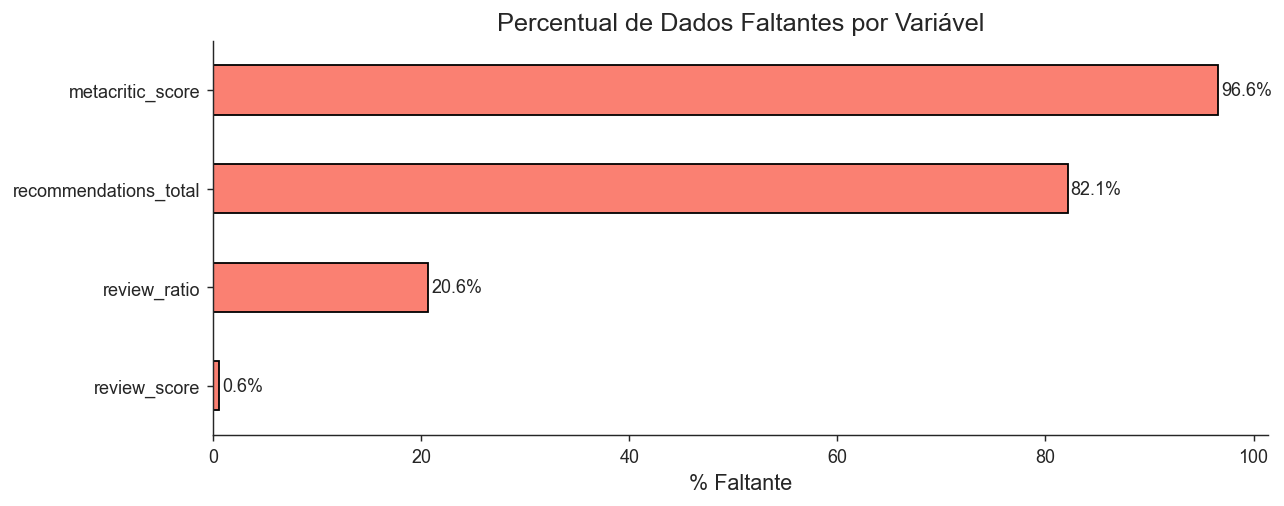

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Faltantes": missing, "% do Total": missing_pct}).sort_values("Faltantes", ascending=False)
missing_com_falha = missing_df[missing_df["Faltantes"] > 0]

if missing_com_falha.empty:
    print("Nenhum dado faltante nas colunas do modelo.")
else:
    print(missing_com_falha.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
missing_com_falha["% do Total"].plot(kind="barh", ax=ax, color="salmon", edgecolor="black")
ax.set_title("Percentual de Dados Faltantes por Variável")
ax.set_xlabel("% Faltante")
ax.invert_yaxis()
for i, v in enumerate(missing_com_falha["% do Total"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_01_dados_faltantes.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Variável-Alvo: Popularidade (`reviews_total`)

Uso `reviews_total` como proxy de popularidade — só quem comprou o jogo pode avaliar na Steam, então o total de avaliações fica diretamente proporcional ao engajamento e ao tamanho da base de jogadores de cada título.

Uma coisa que eu tinha deixado como pendência: o professor comentou sobre "multiplicar por 20" pra estimar o total de compradores a partir do número de avaliações. Pesquisei — é o chamado **método Boxleiter** (derivado por Jake Birkett em 2014/2018, adotado depois por SteamSpy e por sites como Gamalytic e GameDiscoverCo): a lógica é `compradores ≈ avaliações × multiplicador`, já que só uma fração de quem compra deixa review. O problema é que esse multiplicador não é nada estável — a análise original do Birkett achou de 30x a 100x (mediana ~70x), e estimativas mais recentes (jogos depois de 2020, quando a Steam passou a mostrar um prompt automático de avaliação pós-jogo) caíram bastante, pra faixa de 20x a 50x, variando por gênero. O "20" que o professor comentou bate com essa estimativa mais recente e mais baixa.

Não acho que vale usar isso como pré-processamento ou como variável-alvo — a incerteza do multiplicador é grande demais e não é um número validado oficialmente pela Valve, seria trocar um proxy imperfeito só que já é usado na literatura (inclusive no trabalho da Silva (2023) que já cito) por uma estimativa ainda mais incerta. Onde acho que isso entra é na **discussão dos resultados**: dá pra usar como referência de ordem de grandeza pra contextualizar o que um certo número de avaliações representa em jogadores reais, com a devida citação.

### Distribuição Bruta e Transformação Logarítmica

A distribuição de `reviews_total` tem assimetria positiva extrema: poucos jogos concentram milhões de avaliações e a maioria fica perto de zero. Uso `log(x + 1)` pra deixar a distribuição mais tratável pra modelagem e visualização.

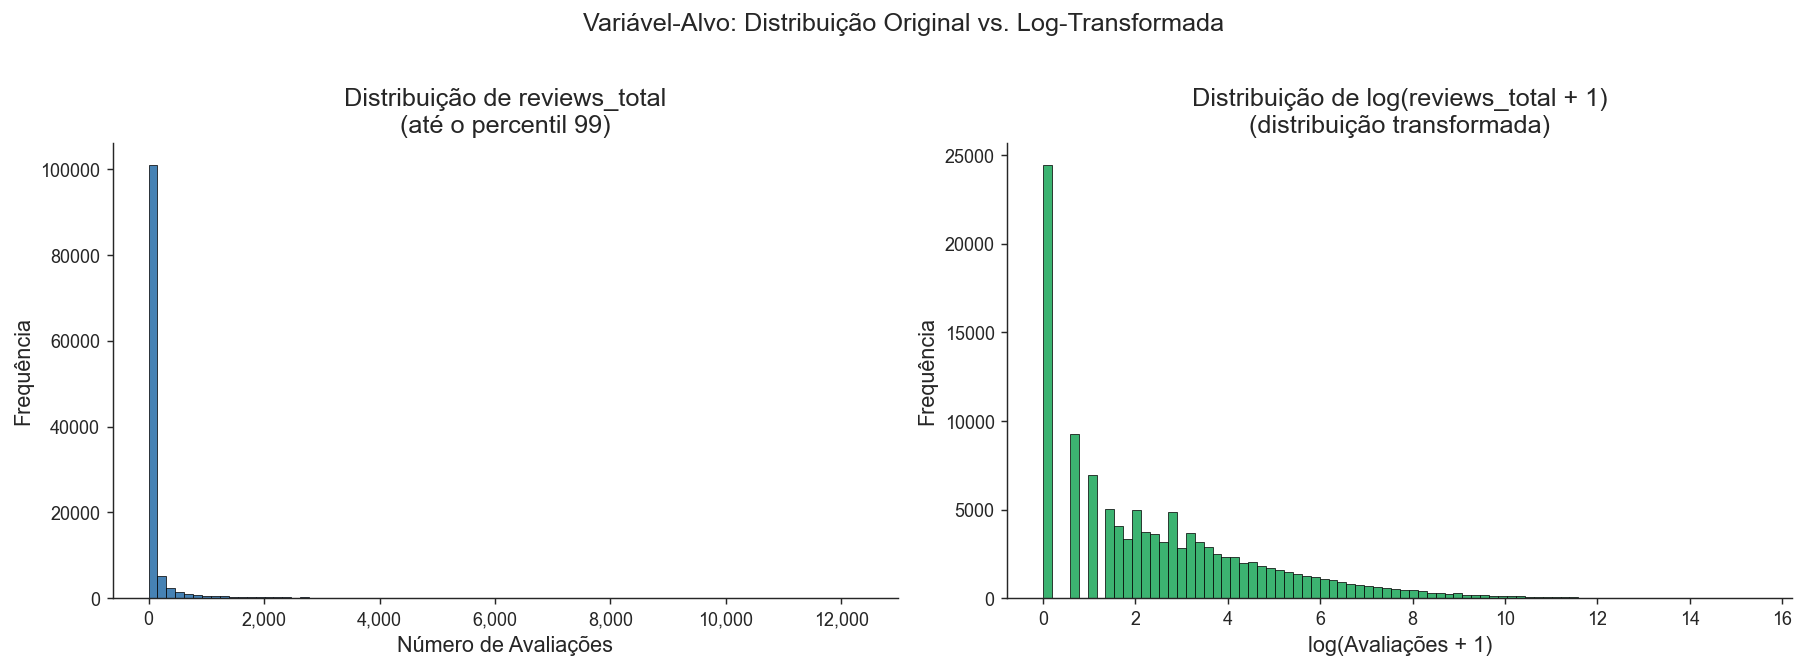

Estatísticas Descritivas de reviews_total
count     118596.00
mean         926.62
std        20896.03
min            0.00
25%            1.00
50%            8.00
75%           48.00
max      5136950.00

Assimetria (skewness): 143.91
Curtose              : 31779.00

Jogos com 0 avaliações: 24,479 (20.6%)


In [7]:
df["log_reviews"] = np.log1p(df["reviews_total"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99 = df["reviews_total"].quantile(0.99)
ax = axes[0]
ax.hist(df[df["reviews_total"] <= p99]["reviews_total"],
        bins=80, color="steelblue", edgecolor="black", linewidth=0.4)
ax.set_title("Distribuição de reviews_total\n(até o percentil 99)")
ax.set_xlabel("Número de Avaliações")
ax.set_ylabel("Frequência")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax = axes[1]
ax.hist(df["log_reviews"], bins=80, color="mediumseagreen", edgecolor="black", linewidth=0.4)
ax.set_title("Distribuição de log(reviews_total + 1)\n(distribuição transformada)")
ax.set_xlabel("log(Avaliações + 1)")
ax.set_ylabel("Frequência")

plt.suptitle("Variável-Alvo: Distribuição Original vs. Log-Transformada", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_02_distribuicao_alvo.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

print("Estatísticas Descritivas de reviews_total")
print(df["reviews_total"].describe().round(2).to_string())
print(f"\nAssimetria (skewness): {df['reviews_total'].skew():.2f}")
print(f"Curtose              : {df['reviews_total'].kurtosis():.2f}")
print(f"\nJogos com 0 avaliações: {(df['reviews_total'] == 0).sum():,} ({(df['reviews_total'] == 0).mean()*100:.1f}%)")

### Top 20 Jogos Mais Avaliados

Dá pra usar isso pra entender o "teto" da variável-alvo e ver se tem outlier estranho misturado.

In [8]:
top20 = df.nlargest(20, "reviews_total")[
    ["name", "reviews_total", "reviews_positive", "reviews_negative",
     "review_score_desc", "is_free", "price_brl", "release_year"]
].reset_index(drop=True)
top20.index += 1

top20["reviews_total"] = top20["reviews_total"].apply(lambda x: f"{int(x):,}")
top20["reviews_positive"] = top20["reviews_positive"].apply(lambda x: f"{int(x):,}")
top20["reviews_negative"] = top20["reviews_negative"].apply(lambda x: f"{int(x):,}")
top20["price_brl"] = top20["price_brl"].apply(lambda x: "Grátis" if x == 0 else f"R$ {x:.2f}")
top20.columns = ["Nome", "Total", "Positivas", "Negativas", "Sentimento", "Grátis", "Preço", "Ano"]
top20

,Nome,Total,Positivas,Negativas,Sentimento,Grátis,Preço,Ano
1,Counter-Strike 2,"5,136,950","4,386,336","750,614",Very Positive,True,Grátis,2012.0
2,PUBG: BATTLEGROUNDS,"1,760,712","983,405","777,307",Mixed,True,Grátis,2017.0
3,Tom Clancy's Rainbow Six Siege,"1,244,793","1,031,293","213,500",Very Positive,True,Grátis,2015.0
4,Terraria,"1,219,087","1,189,224","29,863",Overwhelmingly Positive,False,R$ 32.99,2011.0
5,Rust,"1,145,371","999,410","145,961",Very Positive,False,R$ 119.99,2018.0
6,Garry's Mod,"1,073,628","1,041,027","32,601",Overwhelmingly Positive,False,R$ 9.99,2006.0
7,Black Myth: Wukong,"873,856","842,645","31,211",Overwhelmingly Positive,False,R$ 229.99,2024.0
8,Stardew Valley,"872,364","859,453","12,911",Overwhelmingly Positive,False,R$ 24.99,2016.0
9,Cyberpunk 2077,"850,482","740,580","109,902",Very Positive,False,R$ 59.99,2020.0
10,HELLDIVERS™ 2,"828,665","629,226","199,439",Mostly Positive,False,R$ 199.50,2024.0


### Categorização da Popularidade

No notebook anterior eu tinha escrito que "mais de 52%" dos jogos não tinham avaliação nenhuma — isso não bate com o valor real calculado (dá pra ver acima: 20,6%). Deixei o número certo agora. Ainda assim, com a cauda tão longa quanto essa, continuo achando que classificação multiclasse é uma alternativa que vale explorar além da regressão pura. Os limiares abaixo são só uma primeira proposta, baseada na distribuição empírica.

Distribuição por Classe de Popularidade
                     Jogos  % do Total
popularidade_classe                   
Sem Avaliações (0)   24479        20.6
Muito Baixa (1–9)    37473        31.6
Baixa (10–99)        35125        29.6
Moderada (100–999)   15054        12.7
Alta (1.000+)         6465         5.5


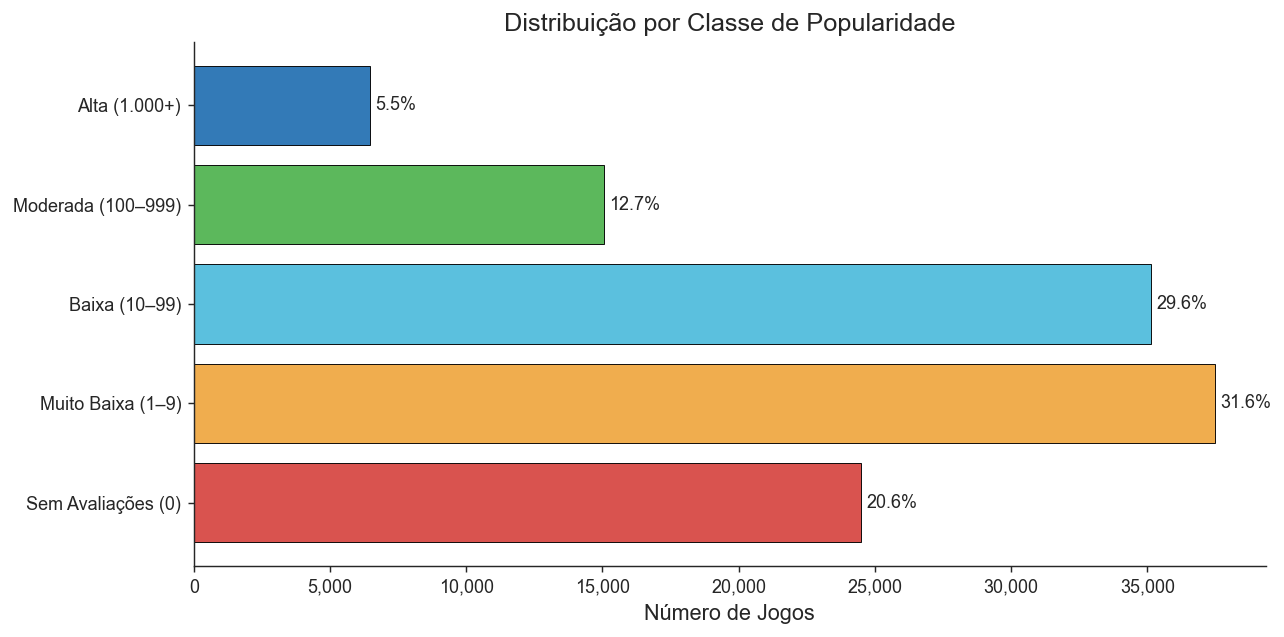

In [9]:
bins   = [-1, 0, 9, 99, 999, float("inf")]
labels = ["Sem Avaliações (0)",
          "Muito Baixa (1–9)",
          "Baixa (10–99)",
          "Moderada (100–999)",
          "Alta (1.000+)"]

df["popularidade_classe"] = pd.cut(df["reviews_total"], bins=bins, labels=labels)
contagem = df["popularidade_classe"].value_counts().reindex(labels)
pct      = (contagem / len(df) * 100).round(1)

resumo_classes = pd.DataFrame({"Jogos": contagem, "% do Total": pct})
print("Distribuição por Classe de Popularidade")
print(resumo_classes.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#d9534f", "#f0ad4e", "#5bc0de", "#5cb85c", "#337ab7"]
bars = ax.barh(resumo_classes.index, resumo_classes["Jogos"],
               color=cores, edgecolor="black", linewidth=0.5)
for bar, pct_val in zip(bars, pct):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{pct_val:.1f}%", va="center", fontsize=10)
ax.set_title("Distribuição por Classe de Popularidade")
ax.set_xlabel("Número de Jogos")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_03_classes_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Análise Univariada das Variáveis Numéricas

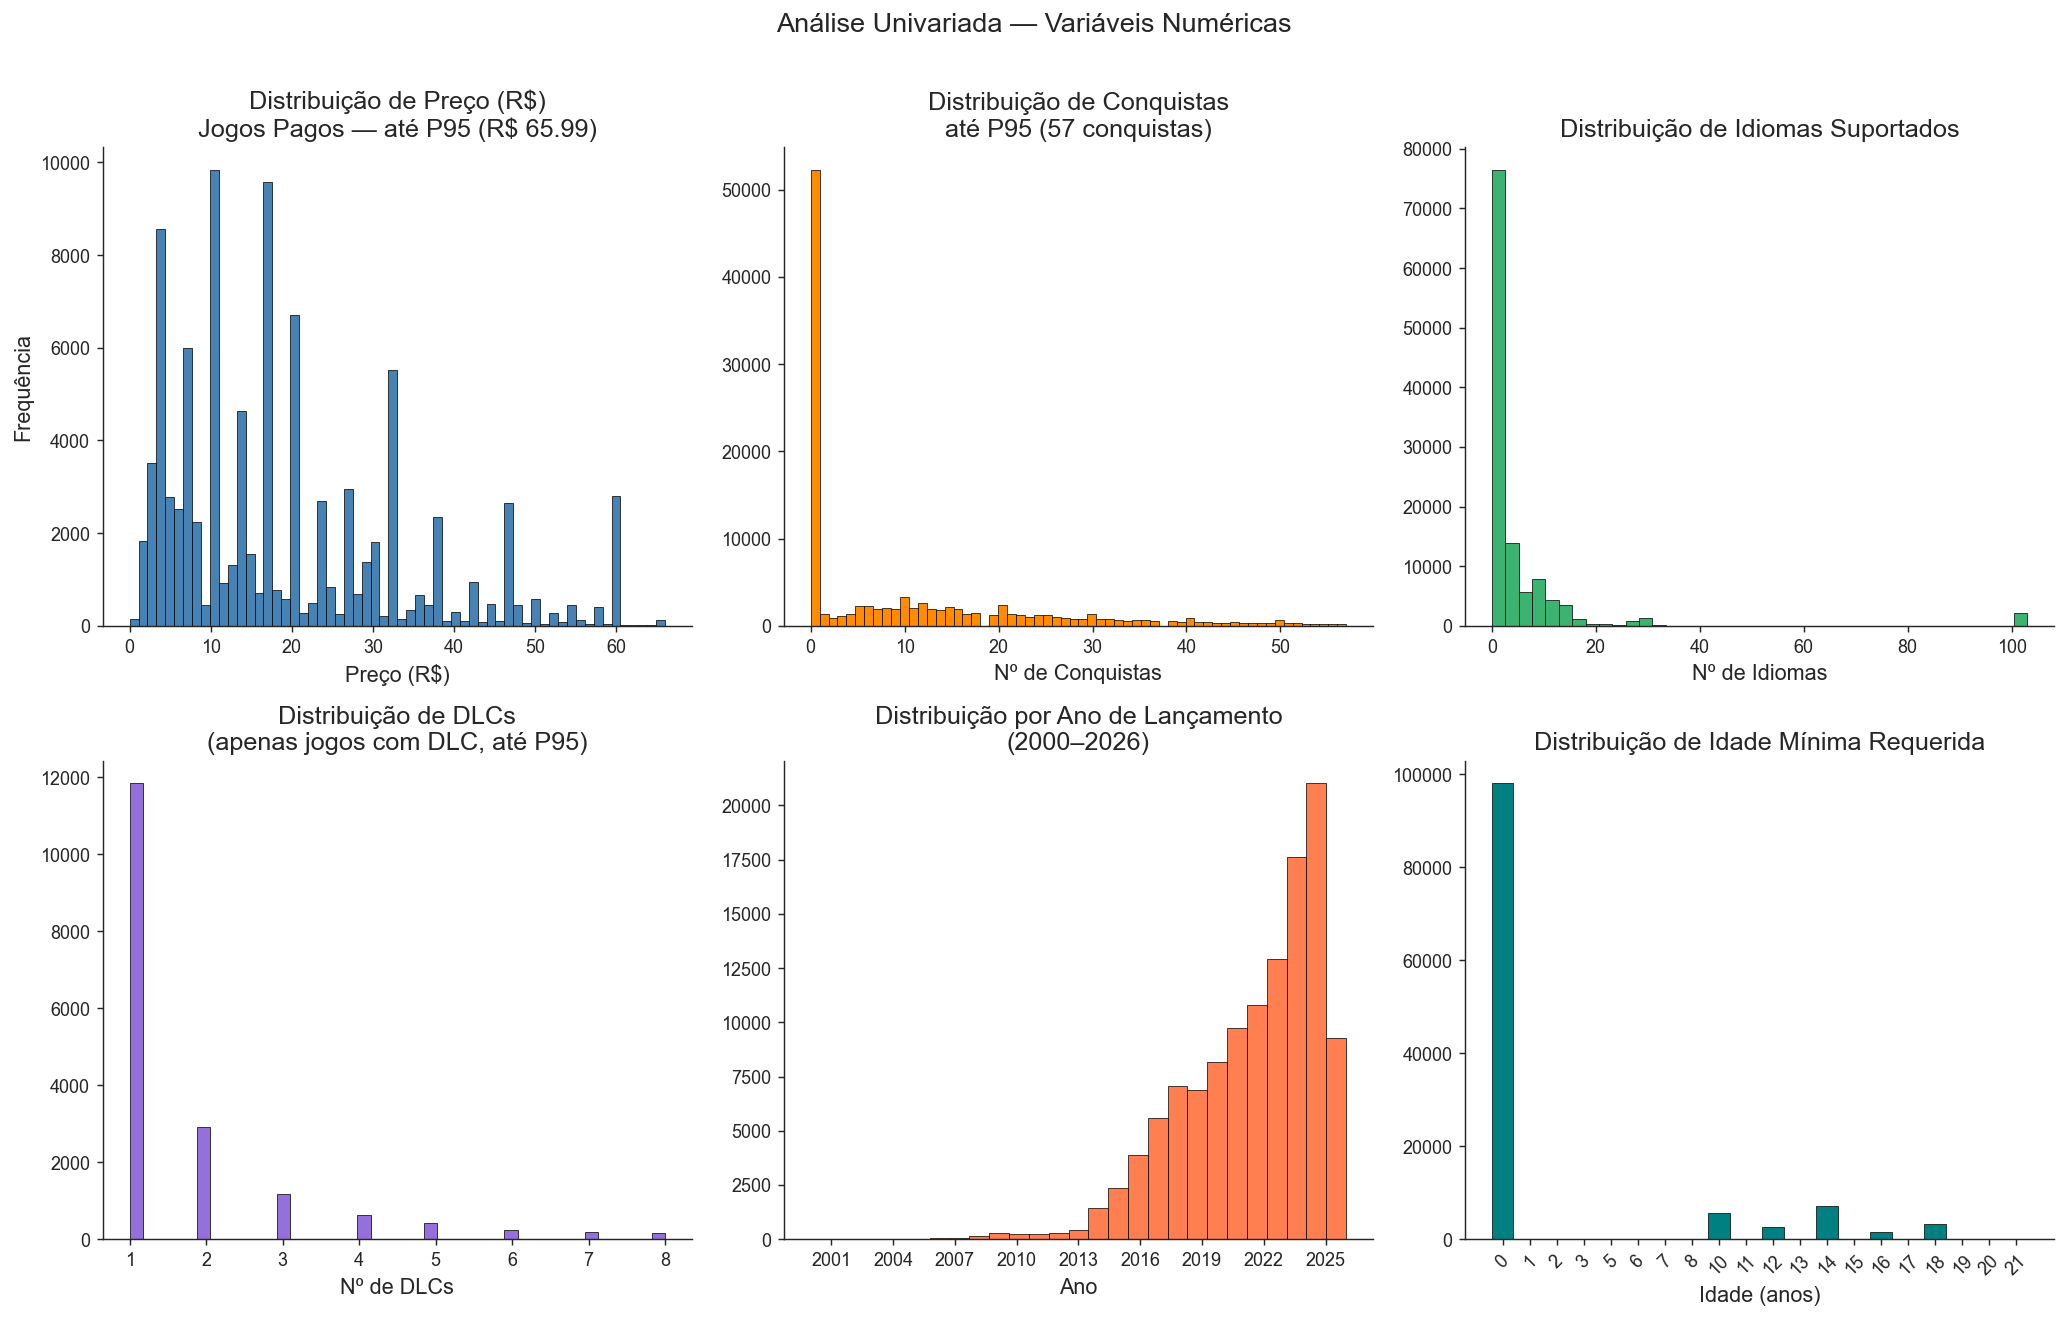

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
price_paid = df[df["is_free"] == False]["price_brl"].dropna()
p95 = price_paid.quantile(0.95)
ax.hist(price_paid[price_paid <= p95], bins=60, color="steelblue", edgecolor="black", lw=0.4)
ax.set_title(f"Distribuição de Preço (R$)\nJogos Pagos — até P95 (R$ {p95:.2f})")
ax.set_xlabel("Preço (R$)")
ax.set_ylabel("Frequência")

ax = axes[0, 1]
ach = df["achievements_total"].dropna()
p95_a = ach.quantile(0.95)
ax.hist(ach[ach <= p95_a], bins=60, color="darkorange", edgecolor="black", lw=0.4)
ax.set_title(f"Distribuição de Conquistas\naté P95 ({int(p95_a)} conquistas)")
ax.set_xlabel("Nº de Conquistas")

ax = axes[0, 2]
langs = df["supported_languages_count"].dropna()
ax.hist(langs, bins=40, color="mediumseagreen", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de Idiomas Suportados")
ax.set_xlabel("Nº de Idiomas")

ax = axes[1, 0]
dlc = df[df["dlc_count"] > 0]["dlc_count"]
p95_d = dlc.quantile(0.95)
ax.hist(dlc[dlc <= p95_d], bins=40, color="mediumpurple", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de DLCs\n(apenas jogos com DLC, até P95)")
ax.set_xlabel("Nº de DLCs")

ax = axes[1, 1]
years = df["release_year"].dropna()
years = years[years.between(2000, 2026)]
ax.hist(years, bins=27, color="coral", edgecolor="black", lw=0.4)
ax.set_title("Distribuição por Ano de Lançamento\n(2000–2026)")
ax.set_xlabel("Ano")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax = axes[1, 2]
age = df["required_age"].value_counts().sort_index()
ax.bar(age.index.astype(str), age.values, color="teal", edgecolor="black", lw=0.4)
ax.set_title("Distribuição de Idade Mínima Requerida")
ax.set_xlabel("Idade (anos)")
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Análise Univariada — Variáveis Numéricas", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_04_variaveis_numericas.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Análise de Gêneros

### Frequência de Gêneros

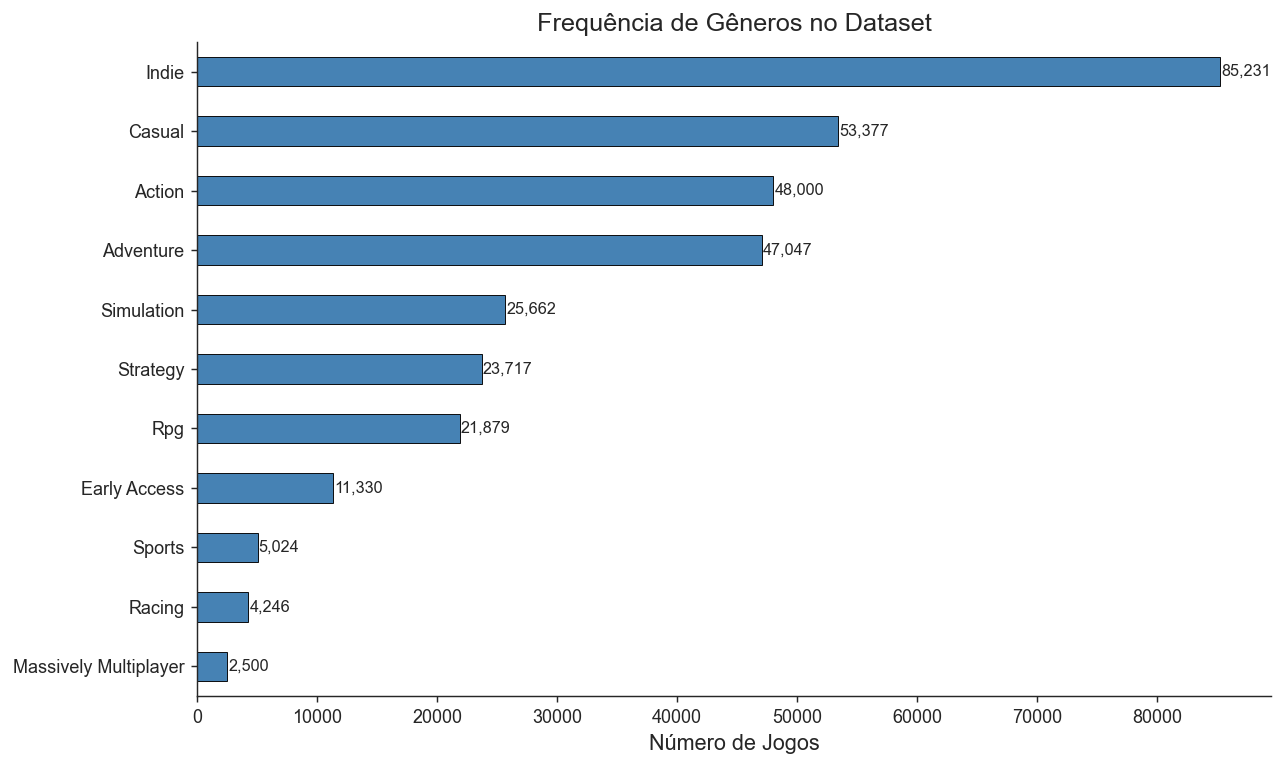

In [11]:
genre_cols = [c for c in df.columns if c.startswith("genre_")]
genre_counts = df[genre_cols].sum().sort_values(ascending=True)
genre_counts.index = (genre_counts.index.str.replace("genre_", "").str.replace("_", " ").str.title())

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black", lw=0.5)
ax.set_title("Frequência de Gêneros no Dataset")
ax.set_xlabel("Número de Jogos")
for i, v in enumerate(genre_counts):
    ax.text(v + 100, i, f"{int(v):,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_05_generos_frequencia.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

### Popularidade Média por Gênero

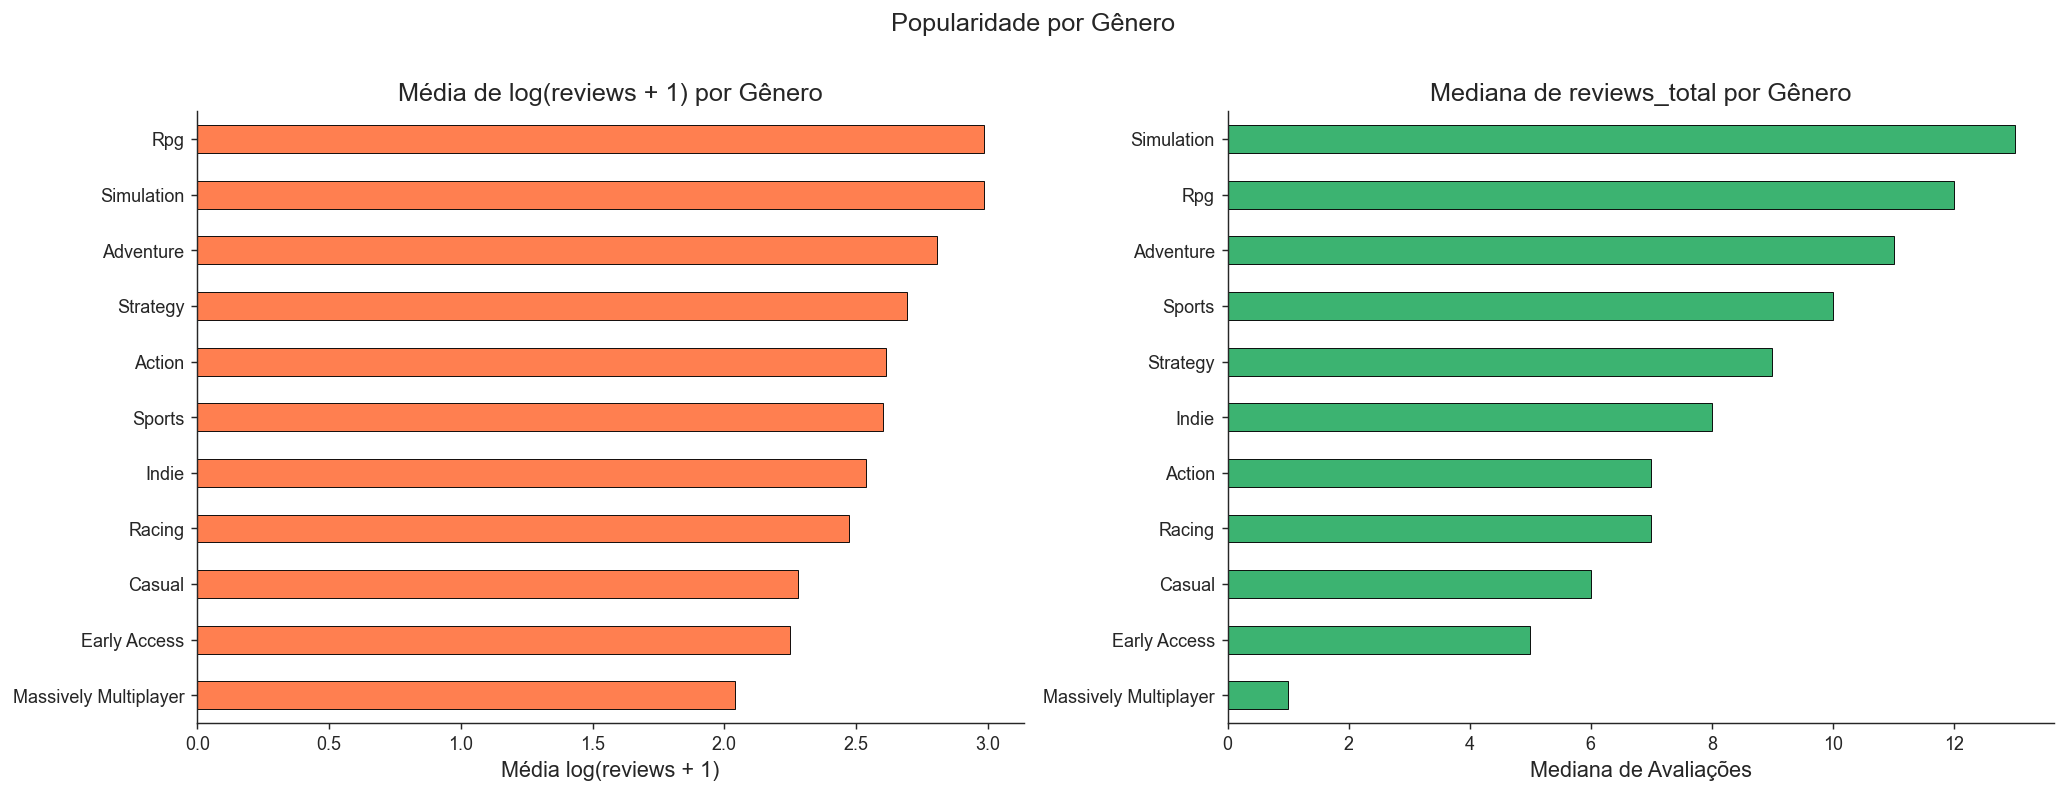

In [12]:
genre_log_means = {}
genre_med_total  = {}

for col in genre_cols:
    name = col.replace("genre_", "").replace("_", " ").title()
    subset = df[df[col] == 1]
    genre_log_means[name] = subset["log_reviews"].mean()
    genre_med_total[name] = subset["reviews_total"].median()

mean_series = pd.Series(genre_log_means).sort_values()
med_series  = pd.Series(genre_med_total).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
mean_series.plot(kind="barh", ax=ax, color="coral", edgecolor="black", lw=0.5)
ax.set_title("Média de log(reviews + 1) por Gênero")
ax.set_xlabel("Média log(reviews + 1)")

ax = axes[1]
med_series.plot(kind="barh", ax=ax, color="mediumseagreen", edgecolor="black", lw=0.5)
ax.set_title("Mediana de reviews_total por Gênero")
ax.set_xlabel("Mediana de Avaliações")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Popularidade por Gênero", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_06_generos_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Análise de Categorias e Características de Jogabilidade

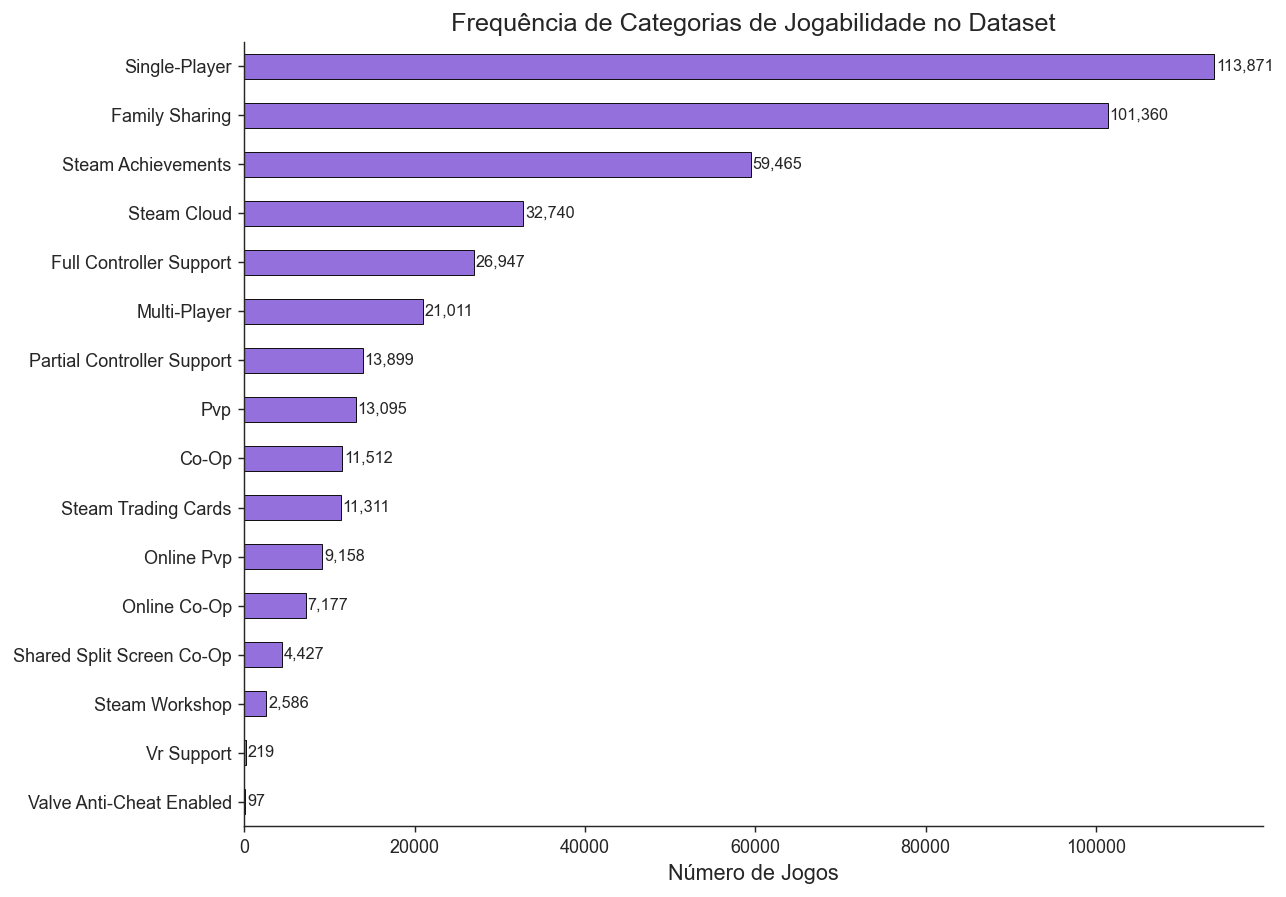

In [13]:
cat_cols = [c for c in df.columns if c.startswith("cat_")]
cat_counts = df[cat_cols].sum().sort_values(ascending=True)
cat_counts.index = (cat_counts.index.str.replace("cat_", "").str.replace("_", " ").str.title())

fig, ax = plt.subplots(figsize=(10, 7))
cat_counts.plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="black", lw=0.5)
ax.set_title("Frequência de Categorias de Jogabilidade no Dataset")
ax.set_xlabel("Número de Jogos")
for i, v in enumerate(cat_counts):
    ax.text(v + 200, i, f"{int(v):,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_07_categorias_frequencia.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

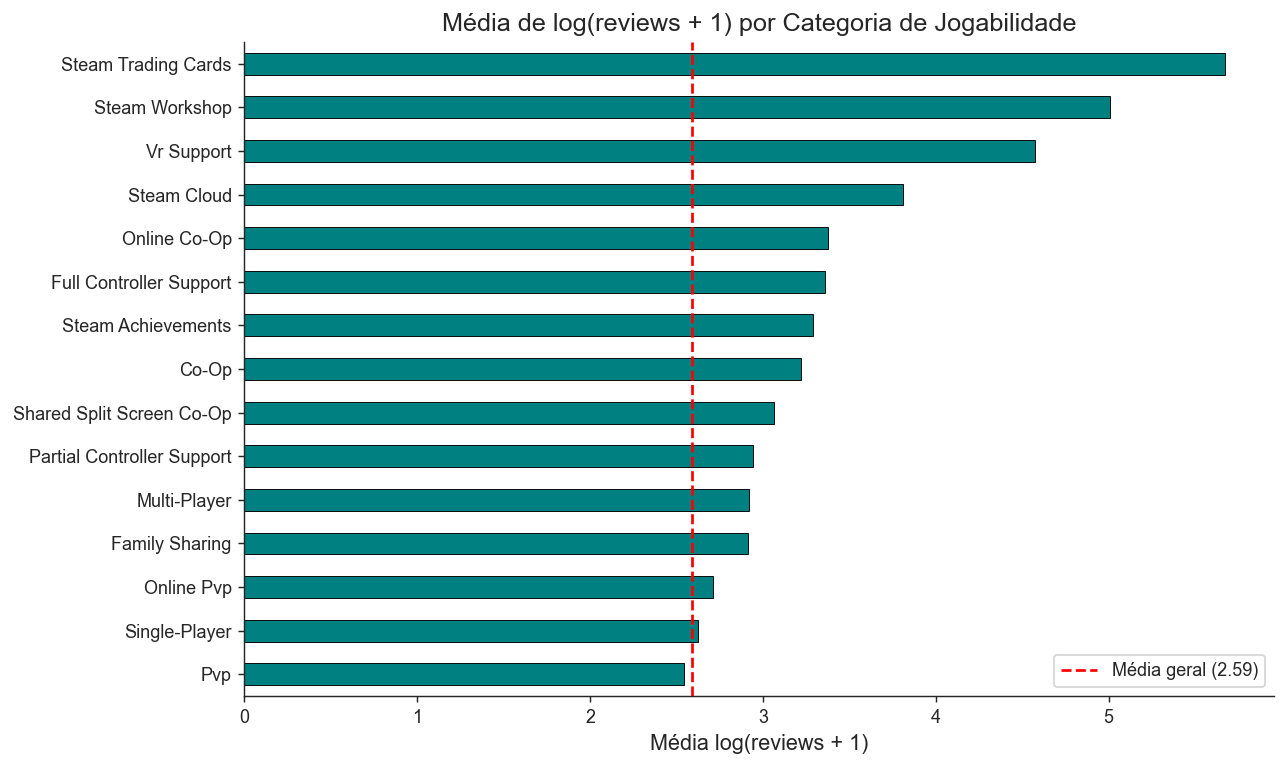

In [14]:
cat_log_means = {}
for col in cat_cols:
    name = col.replace("cat_", "").replace("_", " ").title()
    subset = df[df[col] == 1]
    if len(subset) > 100:
        cat_log_means[name] = subset["log_reviews"].mean()

cat_mean_series = pd.Series(cat_log_means).sort_values()
media_geral = df["log_reviews"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
cat_mean_series.plot(kind="barh", ax=ax, color="teal", edgecolor="black", lw=0.5)
ax.axvline(media_geral, color="red", linestyle="--", linewidth=1.5, label=f"Média geral ({media_geral:.2f})")
ax.set_title("Média de log(reviews + 1) por Categoria de Jogabilidade")
ax.set_xlabel("Média log(reviews + 1)")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_08_categorias_popularidade.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Análise de Plataformas

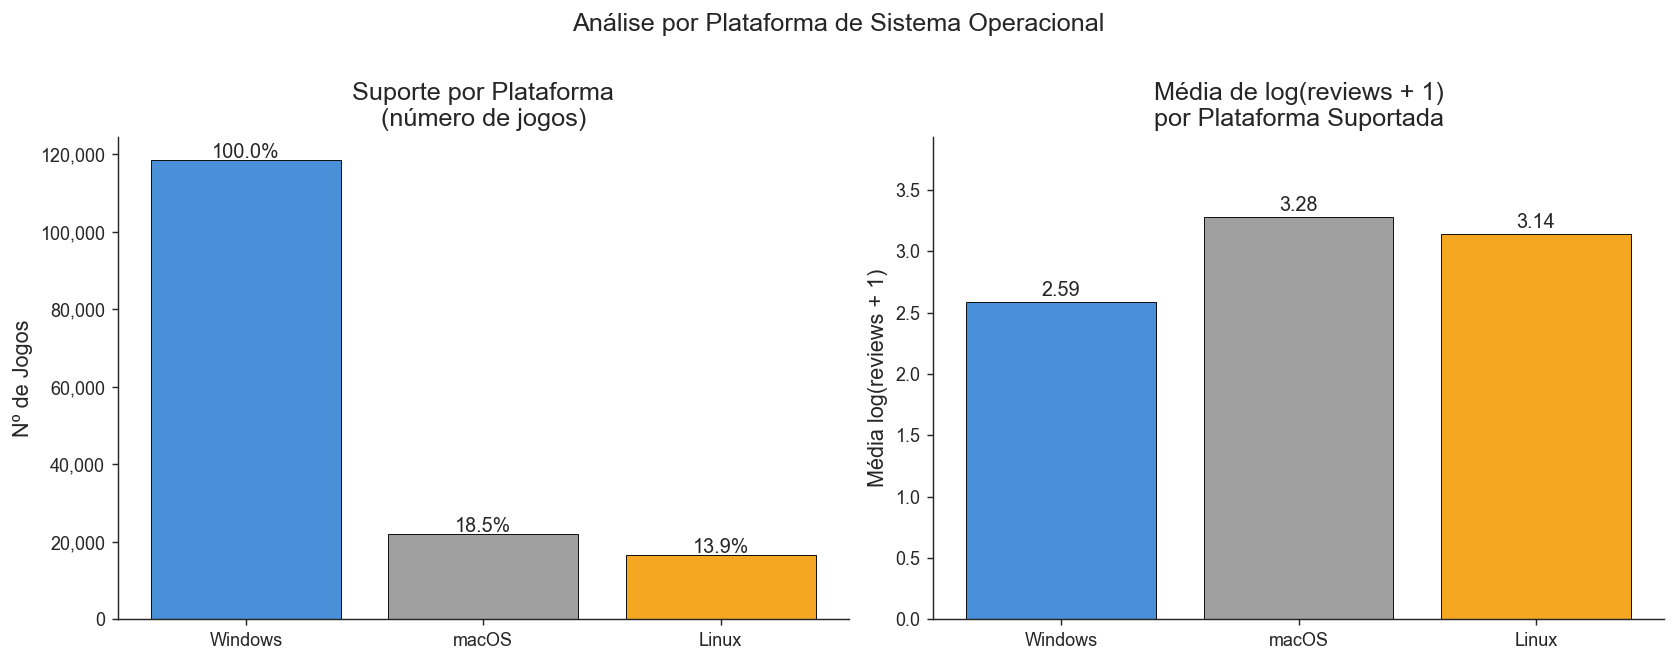

In [15]:
plat_data = {"Windows": df["windows"].sum(), "macOS": df["mac"].sum(), "Linux": df["linux"].sum()}
plat_log = {
    "Windows": df[df["windows"] == 1]["log_reviews"].mean(),
    "macOS":   df[df["mac"]     == 1]["log_reviews"].mean(),
    "Linux":   df[df["linux"]   == 1]["log_reviews"].mean(),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(plat_data.keys(), plat_data.values(), color=["#4A90D9", "#A0A0A0", "#F5A623"], edgecolor="black", lw=0.5)
ax.set_title("Suporte por Plataforma\n(número de jogos)")
ax.set_ylabel("Nº de Jogos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (k, v) in enumerate(plat_data.items()):
    pct = v / len(df) * 100
    ax.text(i, v + 500, f"{pct:.1f}%", ha="center", fontsize=11)

ax = axes[1]
ax.bar(plat_log.keys(), plat_log.values(), color=["#4A90D9", "#A0A0A0", "#F5A623"], edgecolor="black", lw=0.5)
ax.set_title("Média de log(reviews + 1)\npor Plataforma Suportada")
ax.set_ylabel("Média log(reviews + 1)")
ax.set_ylim(0, max(plat_log.values()) * 1.2)
for i, (k, v) in enumerate(plat_log.items()):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontsize=11)

plt.suptitle("Análise por Plataforma de Sistema Operacional", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_09_plataformas.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

## Análise Temporal

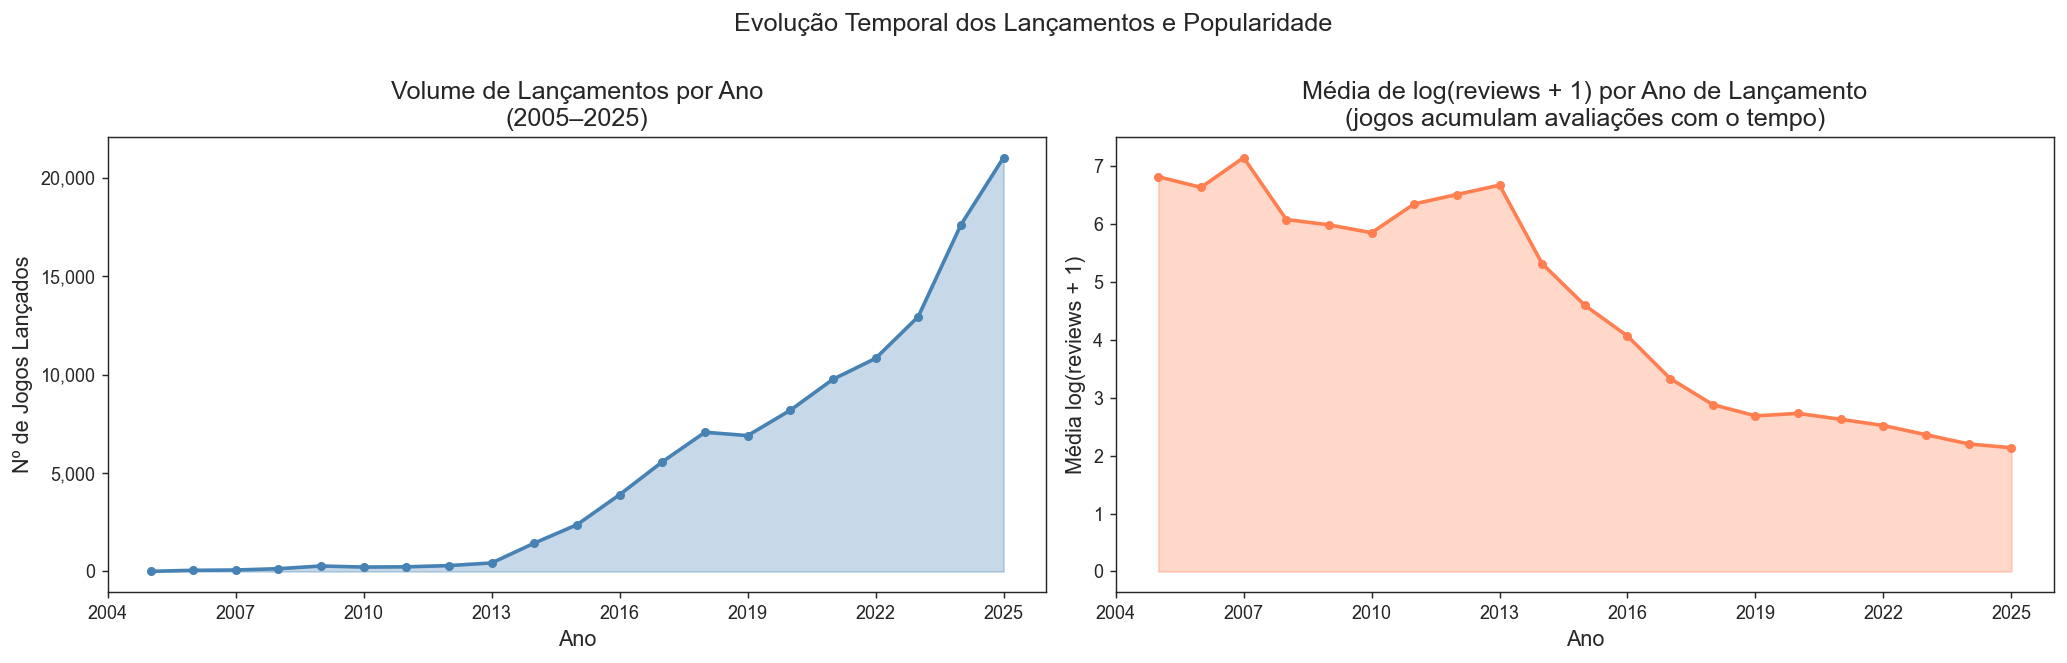

Top 10 Anos com Mais Lançamentos
release_year
2025.0    21015
2024.0    17602
2023.0    12940
2022.0    10820
2021.0     9758
2020.0     8186
2018.0     7069
2019.0     6899
2017.0     5567
2016.0     3902


In [16]:
df_years = df[df["release_year"].between(2005, 2025)].copy()
year_counts = df_years["release_year"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.fill_between(year_counts.index, year_counts.values, alpha=0.3, color="steelblue")
ax.plot(year_counts.index, year_counts.values, color="steelblue", linewidth=2, marker="o", markersize=4)
ax.set_title("Volume de Lançamentos por Ano\n(2005–2025)")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de Jogos Lançados")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

year_log = df_years.groupby("release_year")["log_reviews"].mean()
ax = axes[1]
ax.fill_between(year_log.index, year_log.values, alpha=0.3, color="coral")
ax.plot(year_log.index, year_log.values, color="coral", linewidth=2, marker="o", markersize=4)
ax.set_title("Média de log(reviews + 1) por Ano de Lançamento\n(jogos acumulam avaliações com o tempo)")
ax.set_xlabel("Ano")
ax.set_ylabel("Média log(reviews + 1)")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("Evolução Temporal dos Lançamentos e Popularidade", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_10_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 Anos com Mais Lançamentos")
print(year_counts.sort_values(ascending=False).head(10).to_string())

## Análise de Sentimento do Público (`review_score_desc`)

Vale um comentário importante aqui: essa coluna junta duas situações diferentes sob o mesmo rótulo `"No user reviews"` — jogos com zero avaliações de verdade, e jogos que têm algumas poucas avaliações mas não o suficiente pra Steam calcular uma nota de sentimento (a API devolve algo tipo `"3 user reviews"`, que eu padronizo pra `"No user reviews"` na curadoria). Pra visualização não faz diferença, mas se eu for usar essa coluna como alvo de classificação, preciso ter isso em mente — não é sinônimo de "sem engajamento nenhum".

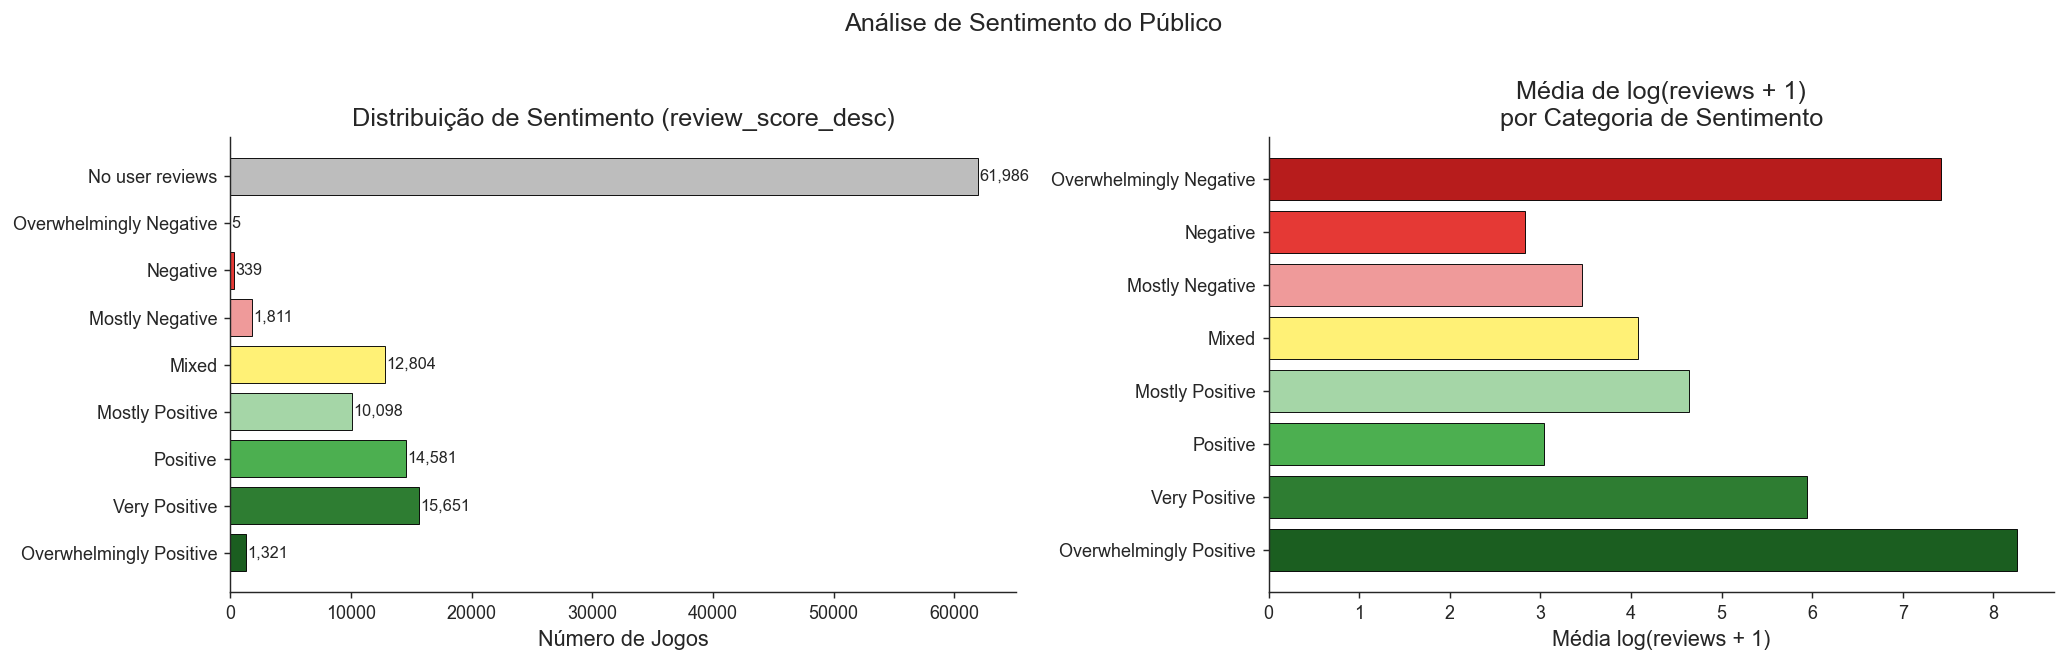

In [17]:
order = ["No user reviews", "Overwhelmingly Negative", "Negative",
         "Mostly Negative", "Mixed", "Mostly Positive",
         "Positive", "Very Positive", "Overwhelmingly Positive"]

score_counts = df["review_score_desc"].value_counts().reindex(order).dropna()

cores_sentimento = {
    "No user reviews"         : "#BDBDBD",
    "Overwhelmingly Negative" : "#B71C1C",
    "Negative"                : "#E53935",
    "Mostly Negative"         : "#EF9A9A",
    "Mixed"                   : "#FFF176",
    "Mostly Positive"         : "#A5D6A7",
    "Positive"                : "#4CAF50",
    "Very Positive"           : "#2E7D32",
    "Overwhelmingly Positive" : "#1B5E20",
}
cores_lista = [cores_sentimento[k] for k in score_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
bars = ax.barh(score_counts.index, score_counts.values, color=cores_lista, edgecolor="black", lw=0.5)
ax.set_title("Distribuição de Sentimento (review_score_desc)")
ax.set_xlabel("Número de Jogos")
ax.invert_yaxis()
for bar in bars:
    w = bar.get_width()
    ax.text(w + 100, bar.get_y() + bar.get_height()/2, f"{int(w):,}", va="center", fontsize=9)

subset_com_reviews = df[df["review_score_desc"] != "No user reviews"]
score_log = (subset_com_reviews.groupby("review_score_desc")["log_reviews"].mean()
             .reindex([s for s in order if s != "No user reviews"]).dropna())
cores_lista2 = [cores_sentimento[k] for k in score_log.index]

ax = axes[1]
ax.barh(score_log.index, score_log.values, color=cores_lista2, edgecolor="black", lw=0.5)
ax.set_title("Média de log(reviews + 1)\npor Categoria de Sentimento")
ax.set_xlabel("Média log(reviews + 1)")
ax.invert_yaxis()

plt.suptitle("Análise de Sentimento do Público", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_11_sentimento.png", dpi=150, bbox_inches="tight")
sns.despine()
plt.show()

Estatísticas do Índice de Aprovação (review_ratio)
Jogos com pelo menos 1 avaliação: 94,117
count    94117.000
mean         0.758
std          0.259
min          0.000
25%          0.647
50%          0.833
75%          0.972
max          1.000


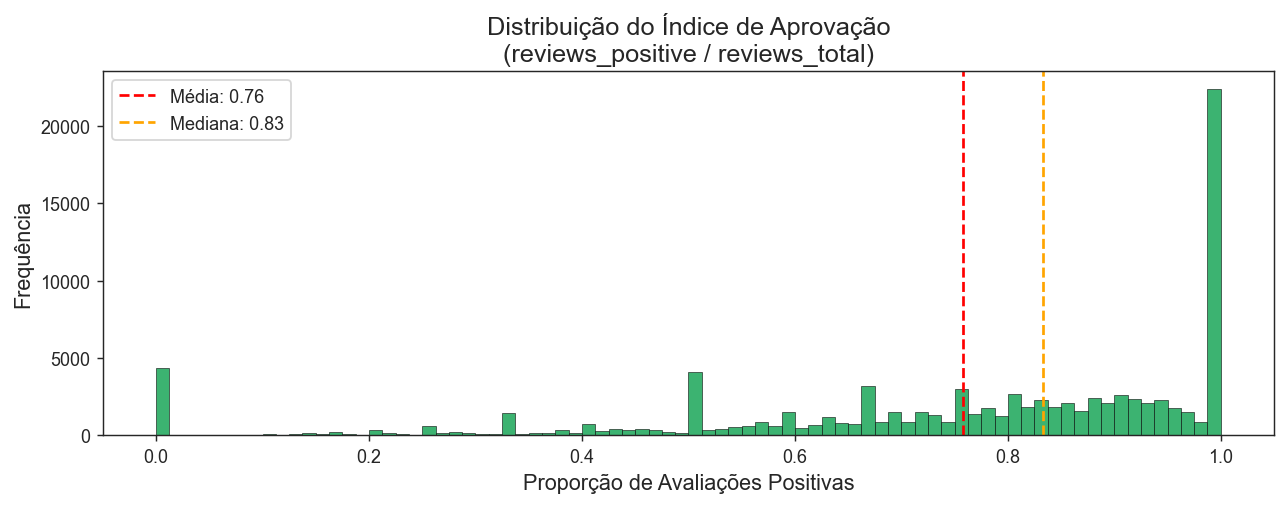

In [18]:
df_com_rev = df[df["reviews_total"] > 0].copy()
df_com_rev["review_ratio"] = df_com_rev["reviews_positive"] / df_com_rev["reviews_total"]

print("Estatísticas do Índice de Aprovação (review_ratio)")
print(f"Jogos com pelo menos 1 avaliação: {len(df_com_rev):,}")
print(df_com_rev["review_ratio"].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_com_rev["review_ratio"], bins=80, color="mediumseagreen", edgecolor="black", lw=0.3)
ax.axvline(df_com_rev["review_ratio"].mean(), color="red", linestyle="--",
           label=f"Média: {df_com_rev['review_ratio'].mean():.2f}")
ax.axvline(df_com_rev["review_ratio"].median(), color="orange", linestyle="--",
           label=f"Mediana: {df_com_rev['review_ratio'].median():.2f}")
ax.set_title("Distribuição do Índice de Aprovação\n(reviews_positive / reviews_total)")
ax.set_xlabel("Proporção de Avaliações Positivas")
ax.set_ylabel("Frequência")
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_12_review_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise de Correlações

Uso correlação de Pearson pra ter uma primeira ideia da associação entre cada preditor e `log_reviews`. Sei que isso só pega relação linear — o que é esperado, já que o Luisa et al. (2021) que cito na revisão bibliográfica já mostrou correlação linear baixa entre atributos estáticos e popularidade em outro dataset da Steam, e é justamente por isso que a rede neural entra no trabalho: pra capturar o que a correlação linear não pega.

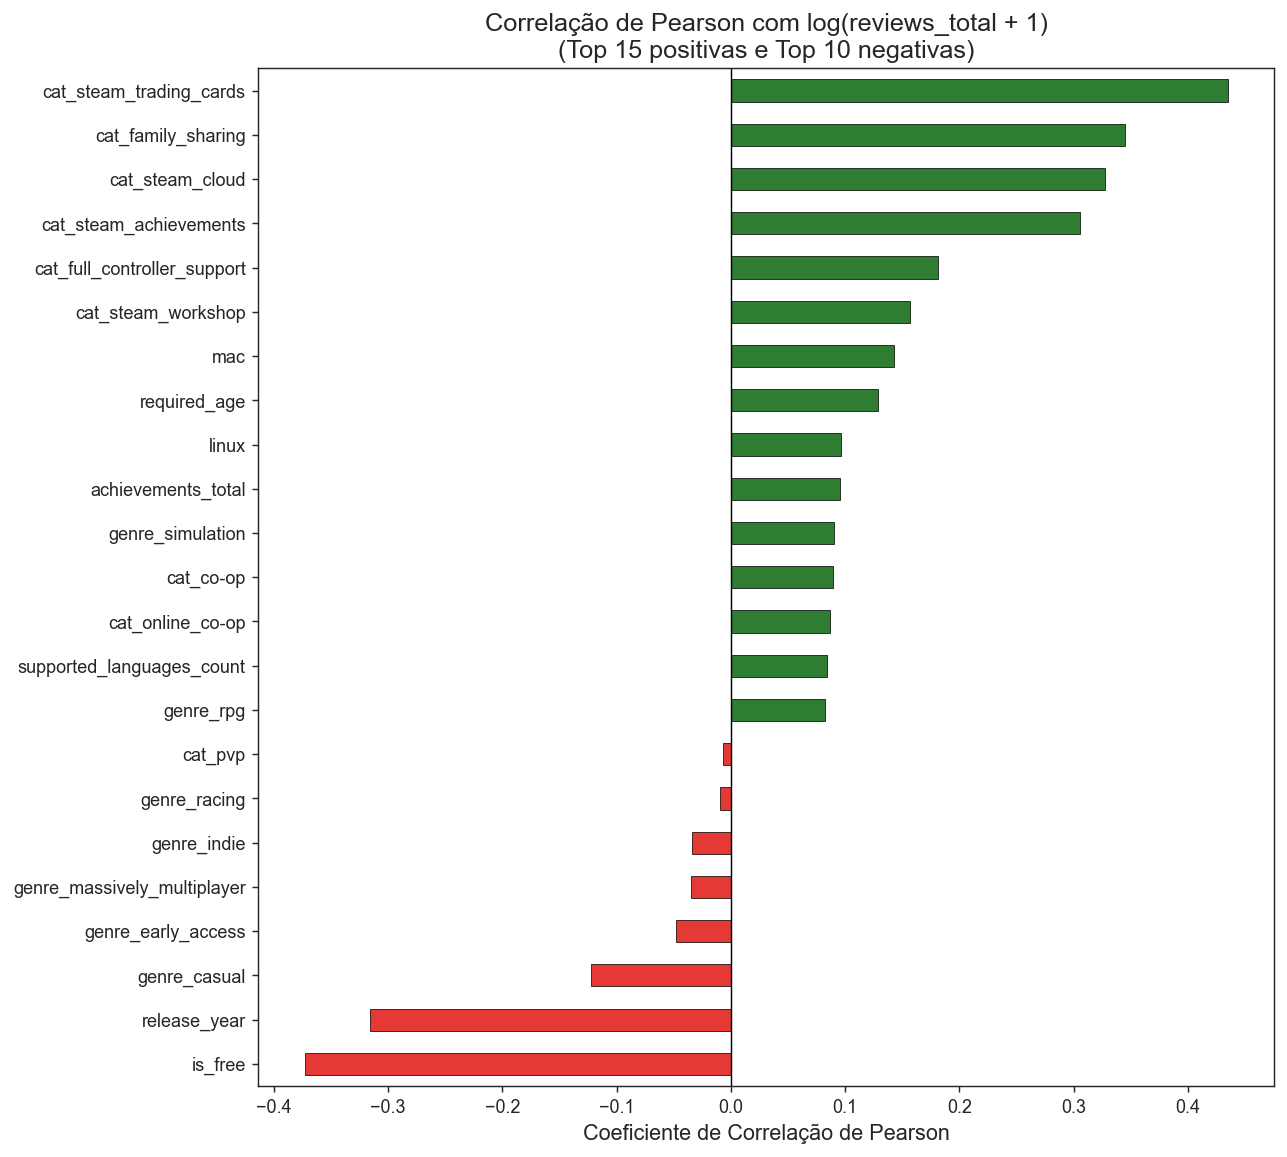

Correlação completa com log_reviews
cat_steam_trading_cards           0.4350
cat_family_sharing                0.3454
cat_steam_cloud                   0.3279
cat_steam_achievements            0.3053
cat_full_controller_support       0.1809
cat_steam_workshop                0.1569
mac                               0.1429
required_age                      0.1286
linux                             0.0963
achievements_total                0.0954
genre_simulation                  0.0903
cat_co-op                         0.0898
cat_online_co-op                  0.0867
supported_languages_count         0.0846
genre_rpg                         0.0822
cat_valve_anti-cheat_enabled      0.0785
genre_adventure                   0.0771
cat_single-player                 0.0743
cat_multi-player                  0.0665
cat_partial_controller_support    0.0560
dlc_count                         0.0533
cat_shared_split_screen_co-op     0.0409
cat_vr_support                    0.0371
genre_strategy       

In [19]:
bool_and_bin_cols = ["is_free", "windows", "mac", "linux"] + genre_cols + cat_cols

corr_df = df[["log_reviews", "price_brl", "achievements_total",
              "release_year", "supported_languages_count",
              "dlc_count", "required_age"] + bool_and_bin_cols].copy()

for col in corr_df.select_dtypes(include="bool").columns:
    corr_df[col] = corr_df[col].astype(int)

corr_target = corr_df.corr()["log_reviews"].drop("log_reviews").sort_values(ascending=False)

top_pos = corr_target[corr_target > 0].head(15)
top_neg = corr_target[corr_target < 0].tail(10)
corr_plot = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#E53935" if v < 0 else "#2E7D32" for v in corr_plot.values]
corr_plot.plot(kind="barh", ax=ax, color=colors, edgecolor="black", lw=0.4)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação de Pearson com log(reviews_total + 1)\n(Top 15 positivas e Top 10 negativas)")
ax.set_xlabel("Coeficiente de Correlação de Pearson")
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_13_correlacao_target.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlação completa com log_reviews")
print(corr_target.round(4).to_string())

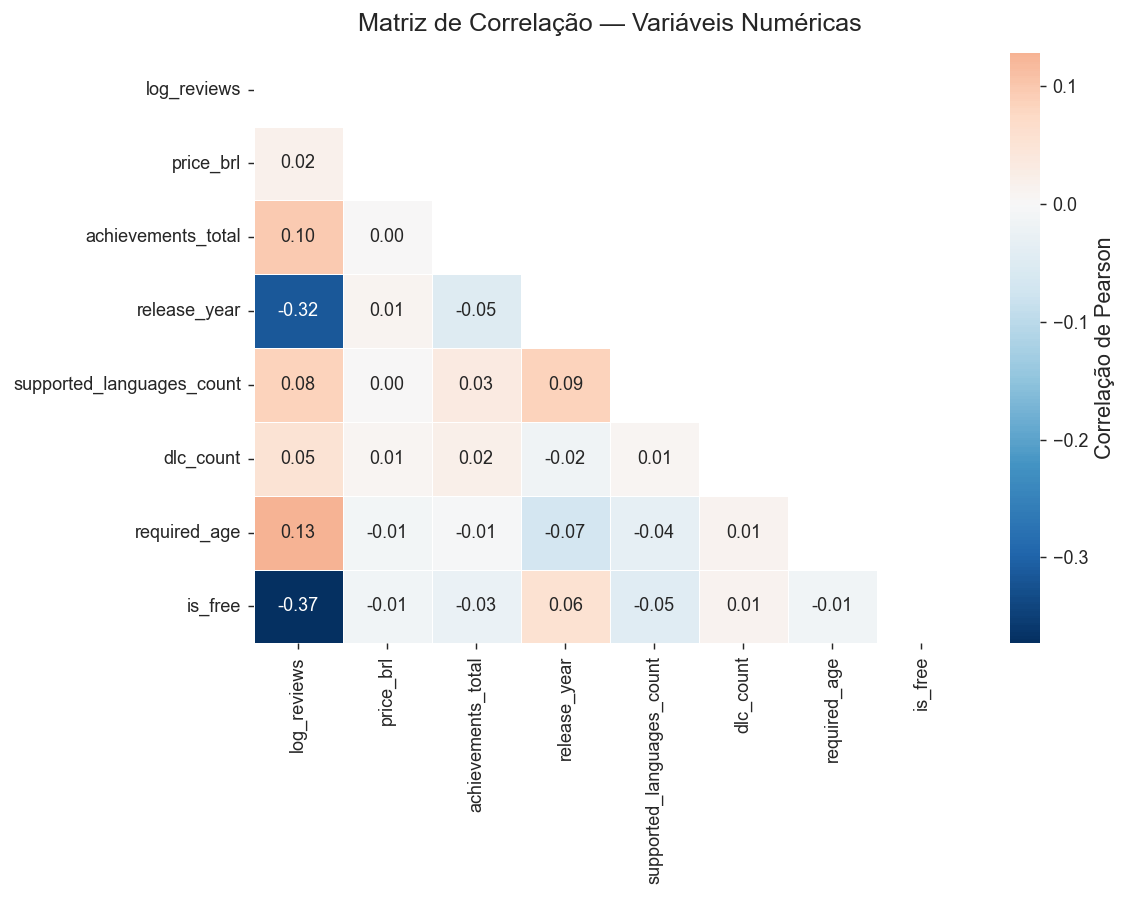

In [20]:
num_cols_hm = ["log_reviews", "price_brl", "achievements_total",
               "release_year", "supported_languages_count", "dlc_count",
               "required_age", "is_free"]

corr_hm = df[num_cols_hm].copy()
corr_hm["is_free"] = corr_hm["is_free"].astype(int)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_hm.corr(), dtype=bool))
sns.heatmap(corr_hm.corr(), mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label": "Correlação de Pearson"})
ax.set_title("Matriz de Correlação — Variáveis Numéricas", pad=12)
plt.tight_layout()
plt.savefig(IMG_DIR / "eda_v2_14_heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

## Síntese e Recomendações para a Modelagem

### Principais Achados

| Aspecto | Observação |
|---|---|
| Escala da variável-alvo | Assimetria extrema; `log1p` é obrigatório pra regressão |
| Concentração em zero | ~20,6% dos jogos não têm avaliação; 75% dos jogos têm ≤ 48 avaliações |
| Gênero predominante | Indie é ~72% do dataset, seguido de Casual (~45%) e Action (~40%) |
| Categoria predominante | Single-player está presente em ~96% dos jogos |
| Crescimento | Volume de lançamentos cresce de forma acentuada a partir de 2014 (expansão do Greenlight / lançamento do Early Access em 2013) e segue subindo após 2017 (Steam Direct substitui o Greenlight) |
| Viés temporal | Jogo mais velho acumula mais avaliação naturalmente — ano de lançamento é confundidor |
| Índice de aprovação | Mediana do `review_ratio` acima de 0,80 — maioria dos jogos avaliados é bem recebida |

### Decisões de Pré-Processamento

```
1. Variável-alvo:
   - Regressão -> log1p(reviews_total); reverter com expm1 nas previsões
   - Classificação -> review_score_desc (9 classes, com a ressalva já comentada) ou popularidade_classe (5 classes)

2. Normalização:
   - Numéricas contínuas (price_brl, achievements_total, etc.) -> StandardScaler ou MinMaxScaler
   - Binárias (gêneros, categorias, plataformas, is_free) -> já em {0,1}, não normalizar

3. Fora do modelo:
   - metacritic_score (96,6% ausente -> viés de seleção severo se incluído)
   - appid, name (identificadores, sem poder preditivo)
   - reviews_positive, reviews_negative, review_ratio, log_reviews (data leakage / é a própria target)
   - recommendations_total (campo legado da 1ª coleta, sujeito ao limiar de visibilidade da API)

4. Engenharia de features:
   - idade do jogo em anos (ano atual - release_year)
   - interação is_free x genre_massively_multiplayer
```

### Próximos Passos

1. Terminar a coleta de tags de jogadores via SteamSpy (`api-atomica-v3.py`)
2. Definir a arquitetura da rede neural (MLP como baseline)
3. Divisão treino/validação/teste estratificada por `popularidade_classe`
4. Comparar regressão (`log_reviews`) e classificação (`review_score_desc` / `popularidade_classe`)

## O que isso muda no TCC

Juntando tudo, acho que preciso mexer em pelo menos estes pontos da Seção 3 (Metodologia) antes da próxima entrega:

1. **Seção 3.1 (Coleta de Dados):** o texto atual descreve só a coleta via `appdetails` (abril de 2026, 159.827 registros) e o problema do `recommendations.total`. Preciso descrever a segunda coleta, que também consulta `/appreviews` e resolve o viés de seleção — com os números novos: 171.769 apps brutos, e a comparação `recommendations` vs `exact_reviews` que fiz na Seção 1 deste notebook (87,6% vs 0,3% de ausência nos mesmos apps).

2. **Tabela 3.2 (percentual de ausentes):** os 86,7% de `reviews_total` ausente não valem mais pro dataset atual — depois da curadoria da V2, `reviews_total` fica sem nenhum ausente (os poucos casos de falha de coleta foram imputados com 0, e são só 0,3% do total, não 86,7%). Preciso refazer essa tabela com os números da V2.

3. **Tabela 3.1 (descrição das variáveis):** falta incluir as colunas que vieram do `exact_reviews` — `reviews_positive`, `reviews_negative`, `review_score`, `review_score_desc` — e explicar que `recommendations_total` (o campo antigo) ficou só como legado/fallback, não é mais a fonte da variável-alvo.

4. **Tamanho do dataset final:** o TCC ainda fala em 159.827 jogos brutos; com a curadoria da V2 e o filtro pra `type == "game"`, o dataset de modelagem tem 118.596 jogos. (Esse número mudou de uma versão pra outra desse notebook — achei um bug de caminho no `steam-analise-v2.py`, que fazia ele salvar o CSV de um jeito que não era mais regenerável a partir do checkpoint atual; corrigi o caminho e rodei a limpeza de novo do zero, e o total real ficou 118.596, não 118.537.)

5. **Seção 3.1.1 / 3.3 (viés de seleção):** o parágrafo sobre viés de seleção continua válido como discussão metodológica (é um achado real e vale manter como aprendizado do processo), mas preciso deixar claro que ele descreve a primeira coleta e foi corrigido na segunda — não é mais uma limitação do dataset final usado na modelagem.

6. Se eu decidir citar a estimativa de compradores via método Boxleiter em algum ponto da discussão, uso a referência do Birkett (2018) que achei — ainda não decidi se entra ou não, foi mais pra fechar aquela dúvida que ficou em aberto.

Ainda não mexi no PDF — quis fechar a AED primeiro pra ter os números certos antes de reescrever o texto.